# Vision Transformer (ViT-B/16) with Weighted BCE

- Backbone: pretrained `vit_b_16` from `torchvision`
- Objective: binary melanoma detection with class weighting

**Objective** <br/>
Evaluate whether a pretrained Vision Transformer can improve anomaly-sensitive classification performance compared with the CNN baselines.

**Key choices** <br/>
- Use ImageNet-pretrained ViT-B/16
- Use `BCEWithLogitsLoss` with `pos_weight` for class imbalance
- Save the best checkpoint using validation F2
- Tune the classification threshold on the validation set before final test evaluation

**Hypothesis** <br/>
A pretrained ViT may capture more global lesion structure than the small CNNs, which could improve recall and F2 on melanoma cases.


### 1. Import libraries
Import the model, training utilities, metrics, and plotting dependencies.


In [1]:
import sys
import os
sys.path.append(os.path.abspath("../.."))

import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

from src.data.dataloader import get_dataloaders
from src.models.vit import get_vit
from src.training.trainer import train_one_epoch, validate_one_epoch

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, classification_report


### 2. Use MPS
Select the Apple Metal device when it is available, otherwise fall back to CPU.


In [2]:
use_mps = True
print("MPS available:", torch.backends.mps.is_available())
device = torch.device("mps" if (use_mps and torch.backends.mps.is_available()) else "cpu")
print(f"Using device: {device}")


MPS available: True
Using device: mps


### 3. Split Dataset and Configure Weighted Loss
Load the train, validation, and test splits, compute class weighting from the training set, and initialize the pretrained ViT model.


In [3]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv="../../data/splits/train.csv",
    val_csv="../../data/splits/val.csv",
    test_csv="../../data/splits/test.csv",
    image_dir="../../data/raw/HAM10000/images",
    batch_size=32,
    image_size=224,
    num_workers=0,
)

train_df = pd.read_csv("../../data/splits/train.csv")

num_melanoma = (train_df["label"] == 0).sum()
num_nevus = (train_df["label"] == 1).sum()

pos_weight = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)
print("pos_weight:", pos_weight)

model = get_vit(num_classes=1, freeze_backbone=False, dropout=0.1).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-4)


pos_weight: tensor([6.0244], device='mps:0')
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /Users/joelyeo/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:09<00:00, 35.1MB/s] 


### 4. Train Model
Train the ViT and keep the checkpoint that achieves the best validation F2 score.


In [4]:
model_save_path = os.path.abspath("../../models/vit_weighted.pth")
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

num_epochs = 10

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
train_f2s = []
val_f2s = []

best_val_f2 = -1.0

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_metrics["loss"])
    val_losses.append(val_metrics["loss"])
    train_accuracies.append(train_metrics["accuracy"])
    val_accuracies.append(val_metrics["accuracy"])
    train_f2s.append(train_metrics["f2"])
    val_f2s.append(val_metrics["f2"])

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_metrics['loss']:.4f}, Train Acc: {train_metrics['accuracy']:.4f}, Train F2: {train_metrics['f2']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Val Acc: {val_metrics['accuracy']:.4f}, Val F2: {val_metrics['f2']:.4f}"
    )

    if val_metrics["f2"] > best_val_f2:
        best_val_f2 = val_metrics["f2"]
        torch.save(model.state_dict(), model_save_path)
        print("Saved best model at epoch", epoch + 1)


Epoch [1/10] | Train Loss: 0.7841, Train Acc: 0.7495, Train F2: 0.6453 | Val Loss: 0.6951, Val Acc: 0.8107, Val F2: 0.6724
Saved best model at epoch 1


Epoch [2/10] | Train Loss: 0.6228, Train Acc: 0.7992, Train F2: 0.7082 | Val Loss: 0.6263, Val Acc: 0.7639, Val F2: 0.7057
Saved best model at epoch 2


Epoch [3/10] | Train Loss: 0.5832, Train Acc: 0.8061, Train F2: 0.7146 | Val Loss: 0.7030, Val Acc: 0.6743, Val F2: 0.6741


Epoch [4/10] | Train Loss: 0.5478, Train Acc: 0.8247, Train F2: 0.7386 | Val Loss: 0.6174, Val Acc: 0.8610, Val F2: 0.7035


Epoch [5/10] | Train Loss: 0.5128, Train Acc: 0.8474, Train F2: 0.7663 | Val Loss: 0.6087, Val Acc: 0.8713, Val F2: 0.7127
Saved best model at epoch 5


Epoch [6/10] | Train Loss: 0.4842, Train Acc: 0.8501, Train F2: 0.7779 | Val Loss: 0.5489, Val Acc: 0.8372, Val F2: 0.7238
Saved best model at epoch 6


Epoch [7/10] | Train Loss: 0.4098, Train Acc: 0.8759, Train F2: 0.8064 | Val Loss: 0.6189, Val Acc: 0.8534, Val F2: 0.7120


Epoch [8/10] | Train Loss: 0.4173, Train Acc: 0.8732, Train F2: 0.8082 | Val Loss: 0.6436, Val Acc: 0.8824, Val F2: 0.7348
Saved best model at epoch 8


Epoch [9/10] | Train Loss: 0.4005, Train Acc: 0.8909, Train F2: 0.8269 | Val Loss: 0.7789, Val Acc: 0.8841, Val F2: 0.6716


Epoch [10/10] | Train Loss: 0.3639, Train Acc: 0.8935, Train F2: 0.8303 | Val Loss: 0.6028, Val Acc: 0.8679, Val F2: 0.7403
Saved best model at epoch 10


### 5. Plot Training Curves
Plot loss, accuracy, and F2 so the optimization behavior can be compared against earlier baselines.


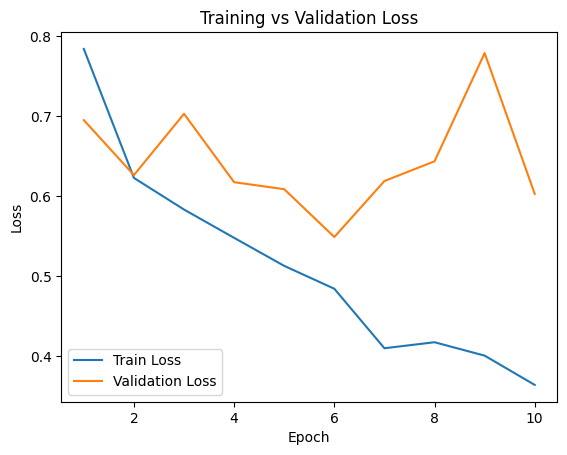

In [5]:
epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


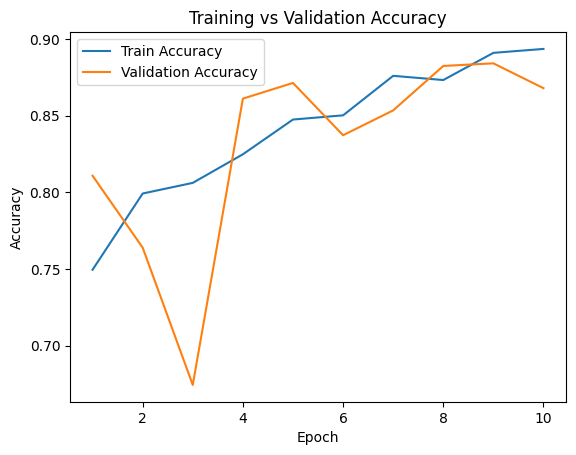

In [6]:
plt.figure()
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()


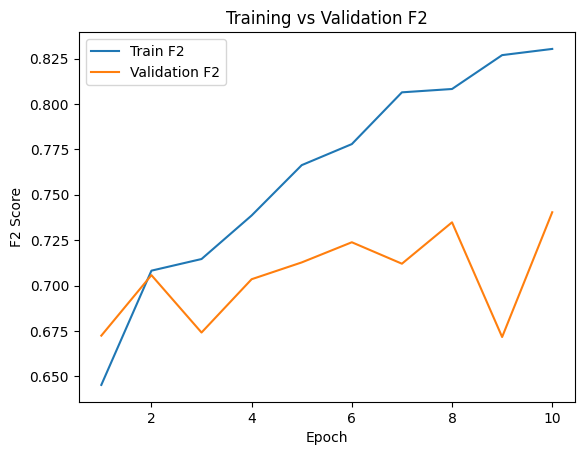

In [7]:
plt.figure()
plt.plot(epochs, train_f2s, label="Train F2")
plt.plot(epochs, val_f2s, label="Validation F2")
plt.xlabel("Epoch")
plt.ylabel("F2 Score")
plt.title("Training vs Validation F2")
plt.legend()
plt.show()


### 6. Tune Threshold on Validation Set
Sweep decision thresholds on the validation set and keep the threshold with the best F2 score before evaluating on the test set.


In [8]:
from sklearn.metrics import fbeta_score, precision_score, recall_score, balanced_accuracy_score
import numpy as np

model.load_state_dict(torch.load(model_save_path, map_location=device))
model.eval()

val_labels = []
val_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze(1)

        val_labels.extend(labels.numpy())
        val_probs.extend(probs.cpu().numpy())

thresholds = np.arange(0.05, 0.95, 0.05)

best_threshold = 0.5
best_f2 = -1

for threshold in thresholds:
    preds = [1 if p >= threshold else 0 for p in val_probs]
    f2 = fbeta_score(val_labels, preds, beta=2)

    print(
        f"Threshold={threshold:.2f} | "
        f"F2={f2:.4f} | "
        f"Precision={precision_score(val_labels, preds):.4f} | "
        f"Recall={recall_score(val_labels, preds):.4f} | "
        f"Balanced Acc={balanced_accuracy_score(val_labels, preds):.4f}"
    )

    if f2 > best_f2:
        best_f2 = f2
        best_threshold = threshold

print(f"\nBest threshold on validation set: {best_threshold:.2f}")


Threshold=0.05 | F2=0.7099 | Precision=0.3396 | Recall=0.9760 | Balanced Acc=0.8305
Threshold=0.10 | F2=0.7201 | Precision=0.3683 | Recall=0.9461 | Balanced Acc=0.8384
Threshold=0.15 | F2=0.7332 | Precision=0.3985 | Recall=0.9281 | Balanced Acc=0.8478
Threshold=0.20 | F2=0.7316 | Precision=0.4148 | Recall=0.9042 | Balanced Acc=0.8462
Threshold=0.25 | F2=0.7433 | Precision=0.4399 | Recall=0.8982 | Balanced Acc=0.8542
Threshold=0.30 | F2=0.7430 | Precision=0.4512 | Recall=0.8862 | Balanced Acc=0.8537
Threshold=0.35 | F2=0.7436 | Precision=0.4723 | Recall=0.8683 | Balanced Acc=0.8536
Threshold=0.40 | F2=0.7508 | Precision=0.4948 | Recall=0.8623 | Balanced Acc=0.8581
Threshold=0.45 | F2=0.7439 | Precision=0.5128 | Recall=0.8383 | Balanced Acc=0.8531
Threshold=0.50 | F2=0.7403 | Precision=0.5227 | Recall=0.8263 | Balanced Acc=0.8505
Threshold=0.55 | F2=0.7486 | Precision=0.5547 | Recall=0.8204 | Balanced Acc=0.8555
Threshold=0.60 | F2=0.7333 | Precision=0.5690 | Recall=0.7904 | Balanced Acc

### 7. Evaluate on Test Set
Run the best validation threshold on the test split and inspect the confusion matrix and classification report.


In [9]:
model.eval()

all_labels = []
all_probs = []
all_preds = []

threshold = best_threshold

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze(1)
        preds = (probs >= threshold).long()

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())


In [10]:
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

print(classification_report(all_labels, all_preds, digits=4))


Confusion Matrix:
[[871 135]
 [ 18 149]]
              precision    recall  f1-score   support

           0     0.9798    0.8658    0.9193      1006
           1     0.5246    0.8922    0.6608       167

    accuracy                         0.8696      1173
   macro avg     0.7522    0.8790    0.7900      1173
weighted avg     0.9150    0.8696    0.8825      1173



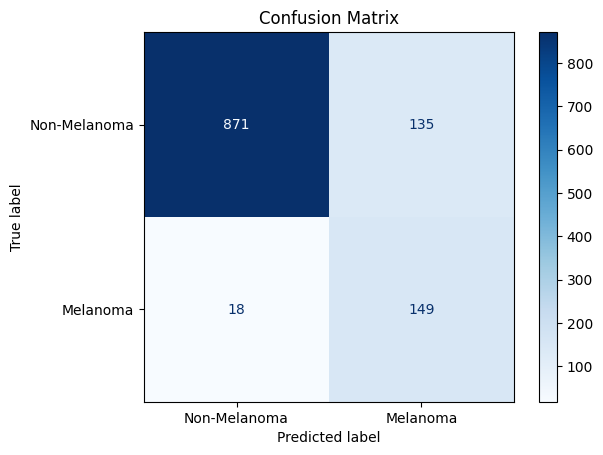

In [11]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Melanoma", "Melanoma"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()
